# 🩸 Blood Cell Classification With PyTorch And ResNet18

A Lightweight Medical AI Project For Blood Cell Classification.

This Project Uses ResNet18 To Classify Human Blood Cells Into Four Categories:

- Eosinophil
- Lymphocyte
- Monocyte
- Neutrophil

Default Training Uses Five Epochs To Keep Training Accessible For CPU And Google Colab Users.

Increasing The Number Of Epochs May Improve Model Performance.

Developed For AltayBioAI.

Installing KaggleHub:

In [ ]:
!pip install -q kagglehub

Imports:

In [52]:
import os
import kagglehub
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from google.colab import files
from torchvision.models import resnet18
import matplotlib.pyplot as plt
from google.colab import files

Download Dataset:

In [ ]:
path = kagglehub.dataset_download(
    "paultimothymooney/blood-cells"
)

print(path)

100%|██████████| 108M/108M [00:00<00:00, 125MB/s] 

Extracting files...


/root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6


Transform:

In [28]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

Train & Test:

In [ ]:
train_path = os.path.join(
    path,
    "dataset2-master",
    "dataset2-master",
    "images",
    "TRAIN"
)

test_path = os.path.join(
    path,
    "dataset2-master",
    "dataset2-master",
    "images",
    "TEST"
)

Dataset:

In [ ]:
train_dataset = ImageFolder(
    train_path,
    transform=transform
)

test_dataset = ImageFolder(
    test_path,
    transform=transform
)

print(train_dataset.classes)

['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


DataLoader:

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

Test DataLoader:

In [ ]:
print("Training Images:", len(train_dataset))
print("Test Images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training Images: 9957
Test Images: 2487
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


Model Building:

In [40]:
model = resnet18(weights=None)
model.fc = nn.Linear(
    model.fc.in_features,
    4
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Device:

In [44]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu")

Loss & Optimizer:

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

Training:

Training Note:
Each Epoch May Take Approximately Four Minutes.
Increasing The Number Of Epochs May Improve Accuracy.
The Default Configuration Uses Five Epochs
To Keep Training Accessible For Google Colab
And CPU Users.

In [45]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(
            outputs,
            labels
        )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

Epoch 1/5 - Loss: 1.0355
Epoch 2/5 - Loss: 0.4786
Epoch 3/5 - Loss: 0.2804
Epoch 4/5 - Loss: 0.1874
Epoch 5/5 - Loss: 0.1170


Accuracy:

In [54]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(
            outputs,
            1
        )
        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(
    f"Accuracy: {accuracy:.2f}%"
)

Accuracy: 68.68%


Showing A Few Images From The Dataset:

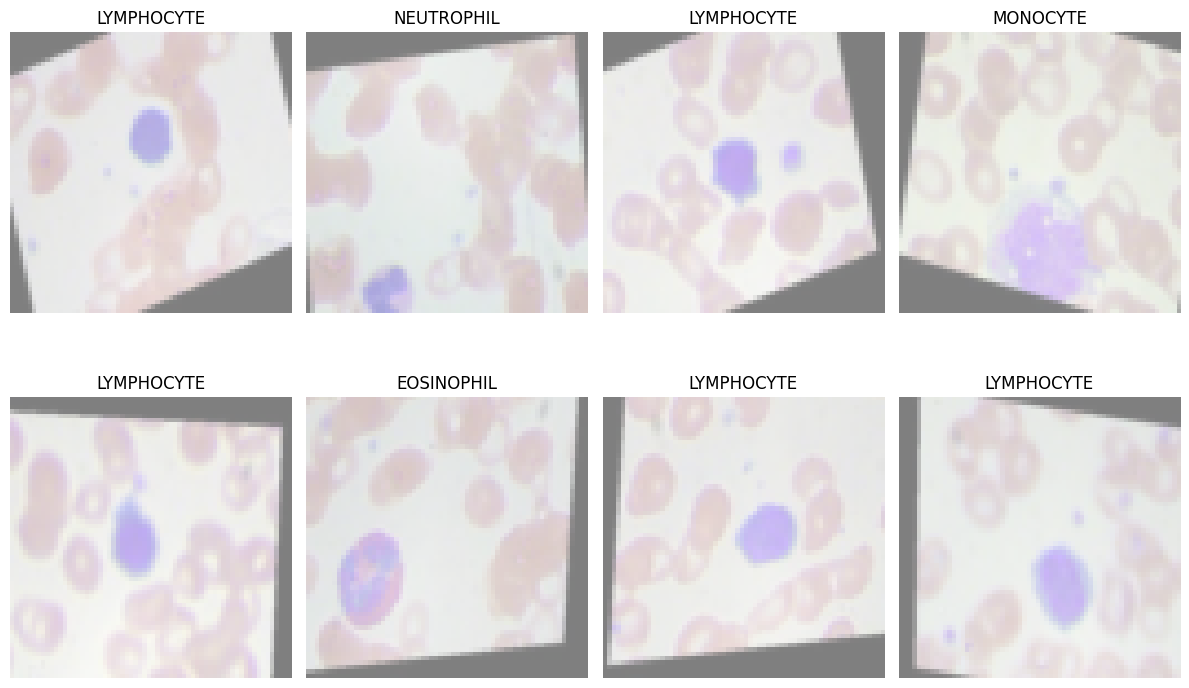

In [49]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    img = images[i].permute(1, 2, 0)
    img = img * 0.5 + 0.5
    plt.imshow(img)
    plt.title(
        train_dataset.classes[
            labels[i]
        ]
    )
    plt.axis("off")

plt.tight_layout()

plt.show()

Show Model Prediction:

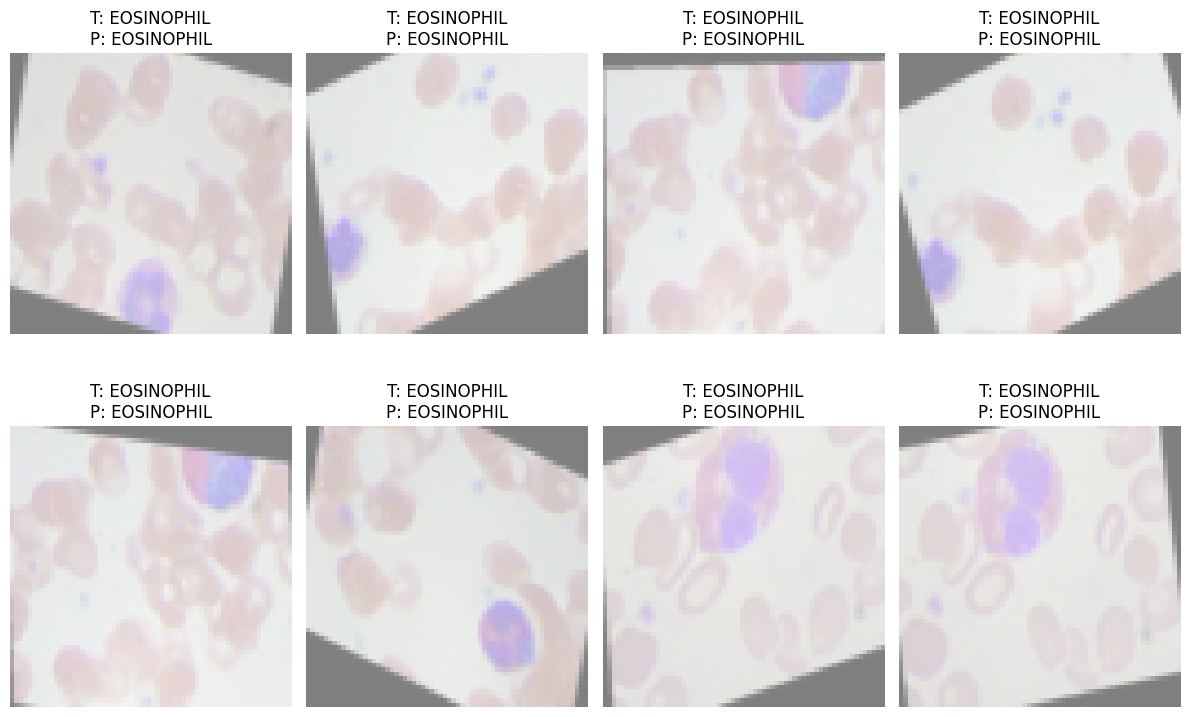

In [50]:
images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images_device)
    _, predictions = torch.max(
        outputs,
        1
    )

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].permute(1,2,0)
    img = img * 0.5 + 0.5
    plt.imshow(img)
    true_label = train_dataset.classes[
        labels[i]
    ]
    pred_label = train_dataset.classes[
        predictions[i].cpu()
    ]
    plt.title(
        f"T: {true_label}\nP: {pred_label}"
    )
    plt.axis("off")

plt.tight_layout()

plt.show()

Save & Download Model:

In [53]:
torch.save(
    model.state_dict(),
    "blood_cell_resnet18.pth"
)

print(
    "Model Saved Successfully!"
)

files.download(
    "blood_cell_resnet18.pth"
)

Model Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Result:

In [51]:
print("Training Completed Successfully.")
print(f"Final Accuracy: {accuracy:.2f}%")

Training Completed Successfully.
Final Accuracy: 68.68%
